In [25]:
from google.colab import files
uploaded=files.upload()

Saving loan_data_new.csv to loan_data_new (1).csv


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree

In [27]:
df = pd.read_csv("loan_data_new.csv")
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df["Person Income"].describe())
print(df["Person Income"].quantile([0.95, 0.99]))

(45000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB
None
Age         

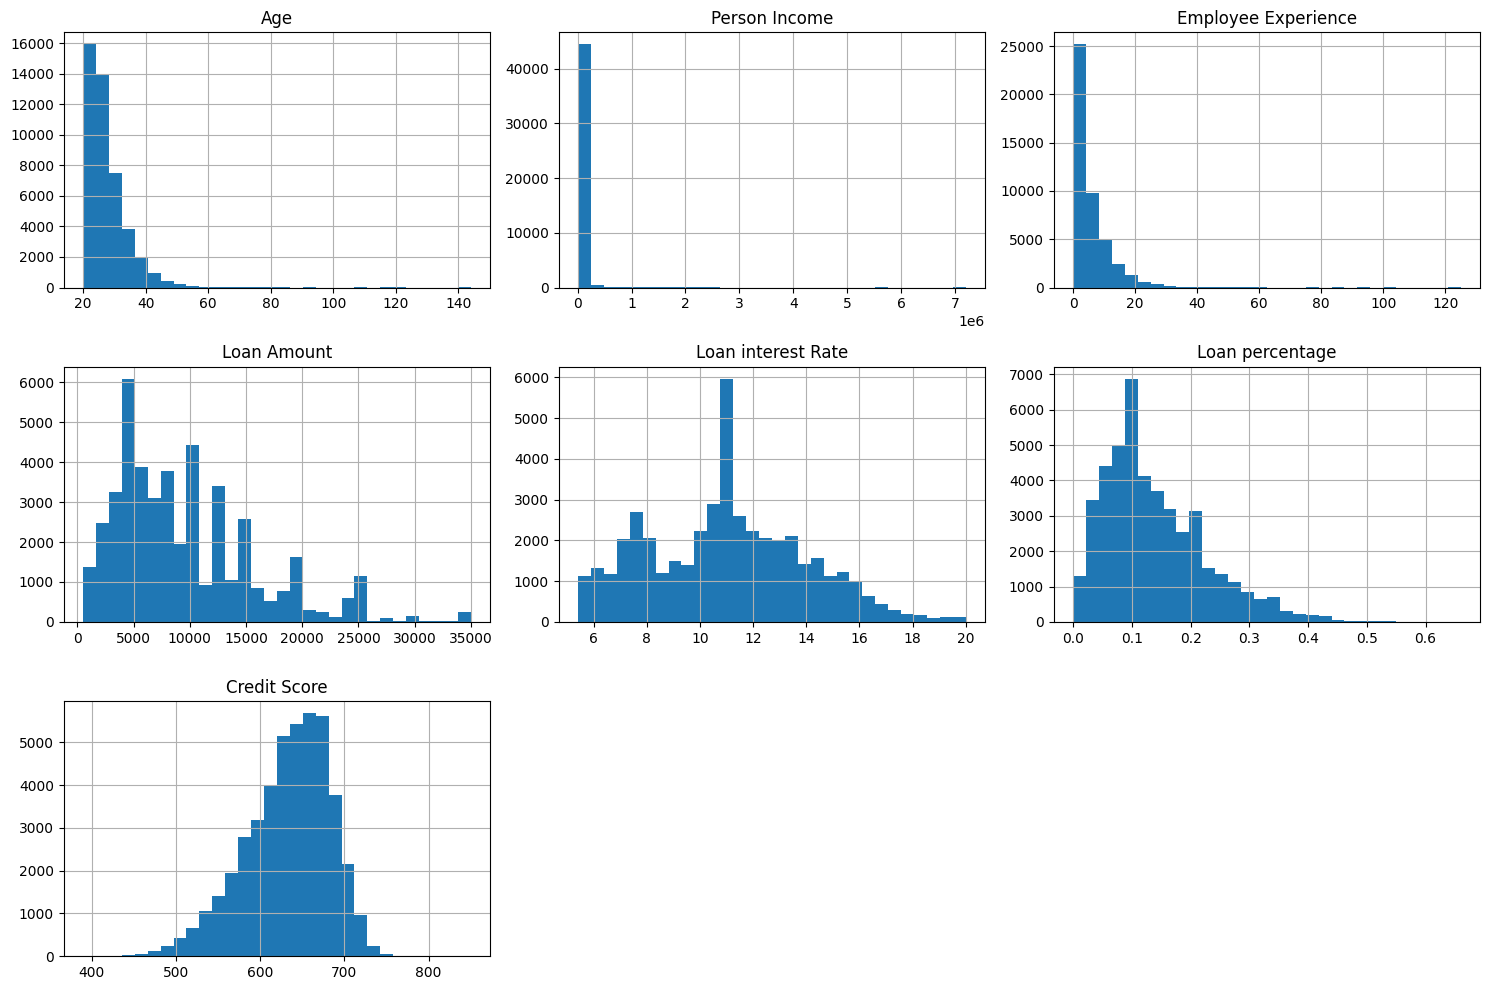

In [28]:
numeric_cols = ["Age", "Person Income", "Employee Experience", "Loan Amount",
                 "Loan interest Rate", "Loan percentage", "Credit Score"]

df[numeric_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

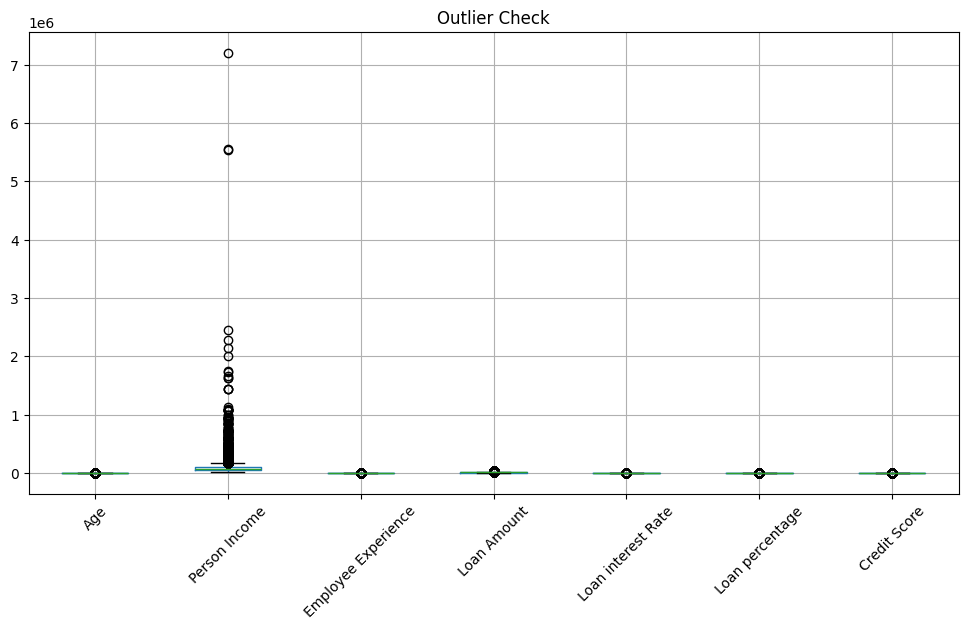

In [29]:
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Outlier Check")
plt.show()

In [30]:
cap_value = df["Person Income"].quantile(0.99)
df["Person Income"] = df["Person Income"].clip(upper=cap_value)

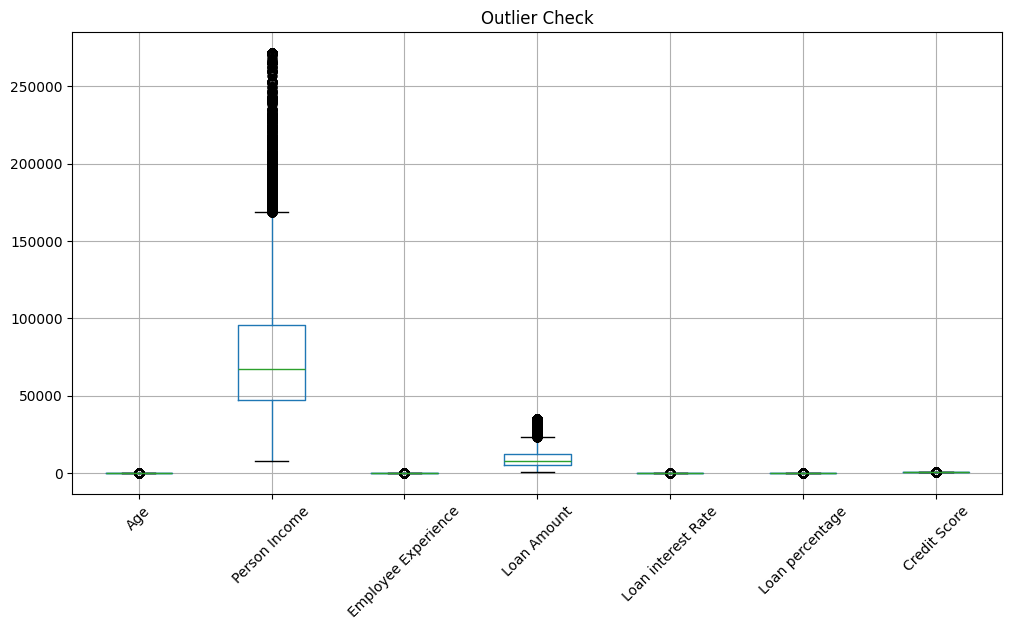

In [31]:
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Outlier Check")
plt.show()

In [32]:
print(df["Loan Status"].value_counts())
print(df["Loan Status"].value_counts(normalize=True) * 100)

Loan Status
0    35000
1    10000
Name: count, dtype: int64
Loan Status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


In [33]:
categorical_cols = ["Gender", "Education", "Home Onwership", "Loan Intent", "Previous Loan"]
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['female' 'male']

Education:
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

Home Onwership:
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

Loan Intent:
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

Previous Loan:
['No' 'Yes']


In [34]:
df["Gender"] = df["Gender"].map({"female": 0, "male": 1})
df["Previous Loan"] = df["Previous Loan"].map({"No": 0, "Yes": 1})
education_map = {"High School": 1, "Associate": 2, "Bachelor": 3, "Master": 4, "Doctorate": 5}
df["Education"] = df["Education"].map(education_map)
nominal_cols = ["Home Onwership", "Loan Intent"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(df.shape)
print(df.dtypes)

(45000, 20)
Age                              int64
Gender                           int64
Education                        int64
Person Income                  float64
Employee Experience              int64
Loan Amount                      int64
Loan interest Rate             float64
Loan percentage                float64
Credit History                   int64
Credit Score                     int64
Previous Loan                    int64
Loan Status                      int64
Home Onwership_OTHER              bool
Home Onwership_OWN                bool
Home Onwership_RENT               bool
Loan Intent_EDUCATION             bool
Loan Intent_HOMEIMPROVEMENT       bool
Loan Intent_MEDICAL               bool
Loan Intent_PERSONAL              bool
Loan Intent_VENTURE               bool
dtype: object


In [35]:
X=df.drop("Loan Status",axis=1)
y=df["Loan Status"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
model = DecisionTreeClassifier(max_depth=6,class_weight="balanced",random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

y_pred_proba = model.predict_proba(X_test)[:, 1]
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7000
           1       0.60      0.94      0.73      2000

    accuracy                           0.84      9000
   macro avg       0.79      0.88      0.81      9000
weighted avg       0.89      0.84      0.86      9000

AUC Score: 0.96040325


In [38]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_custom = (y_pred_proba >= threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred_custom))


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       1.00      0.69      0.82      7000
           1       0.48      1.00      0.65      2000

    accuracy                           0.76      9000
   macro avg       0.74      0.85      0.74      9000
weighted avg       0.88      0.76      0.78      9000


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7000
           1       0.60      0.94      0.73      2000

    accuracy                           0.84      9000
   macro avg       0.79      0.88      0.81      9000
weighted avg       0.89      0.84      0.86      9000


--- Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7000
           1       0.60      0.94      0.73      2000

    accuracy                           0.84      9000
   macro avg       0.79      0.88      0.81      9000
we

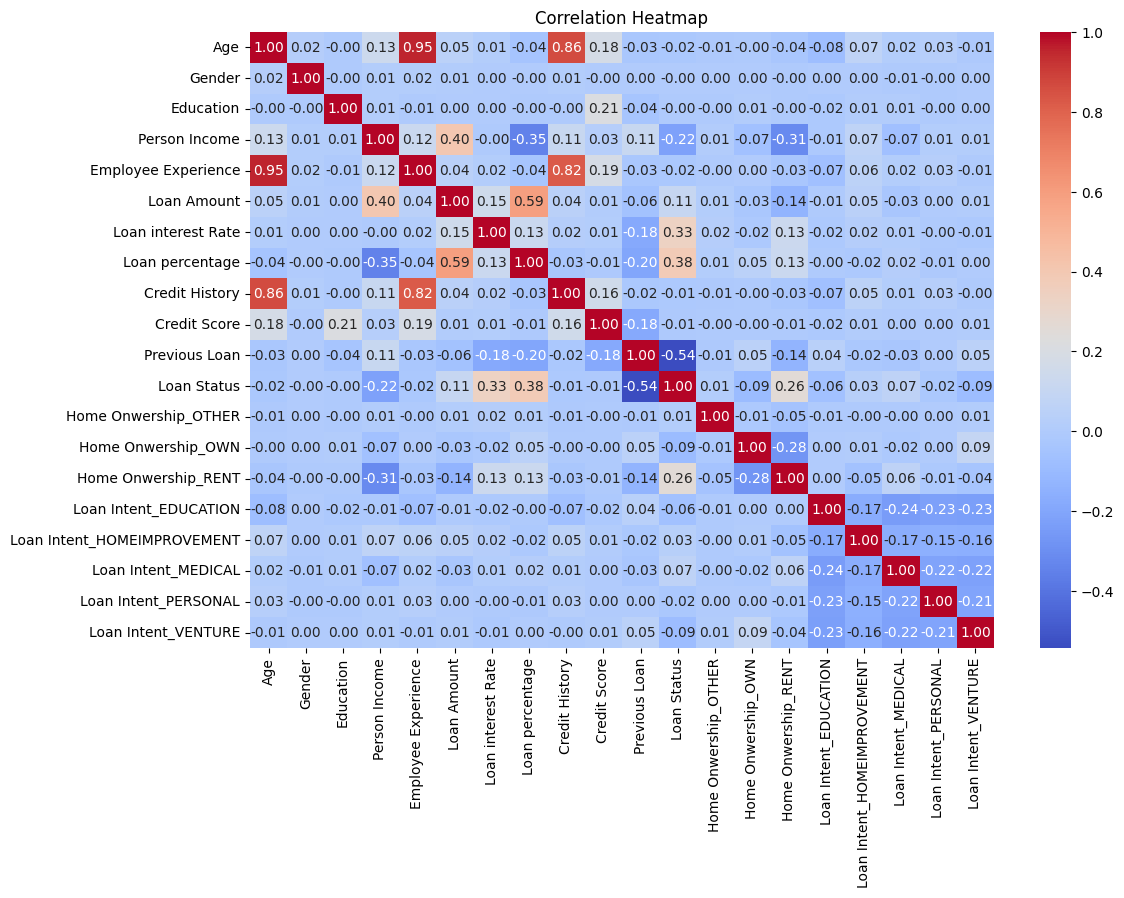

Loan Status                    1.000000
Loan percentage                0.384880
Loan interest Rate             0.332005
Home Onwership_RENT            0.255239
Loan Amount                    0.107714
Loan Intent_MEDICAL            0.065195
Loan Intent_HOMEIMPROVEMENT    0.033838
Home Onwership_OTHER           0.013645
Gender                        -0.000561
Education                     -0.001108
Credit Score                  -0.007647
Credit History                -0.014851
Employee Experience           -0.020481
Age                           -0.021476
Loan Intent_PERSONAL          -0.022488
Loan Intent_EDUCATION         -0.064006
Loan Intent_VENTURE           -0.085992
Home Onwership_OWN            -0.093666
Person Income                 -0.223558
Previous Loan                 -0.543096
Name: Loan Status, dtype: float64


In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
print(df.corr()["Loan Status"].sort_values(ascending=False))

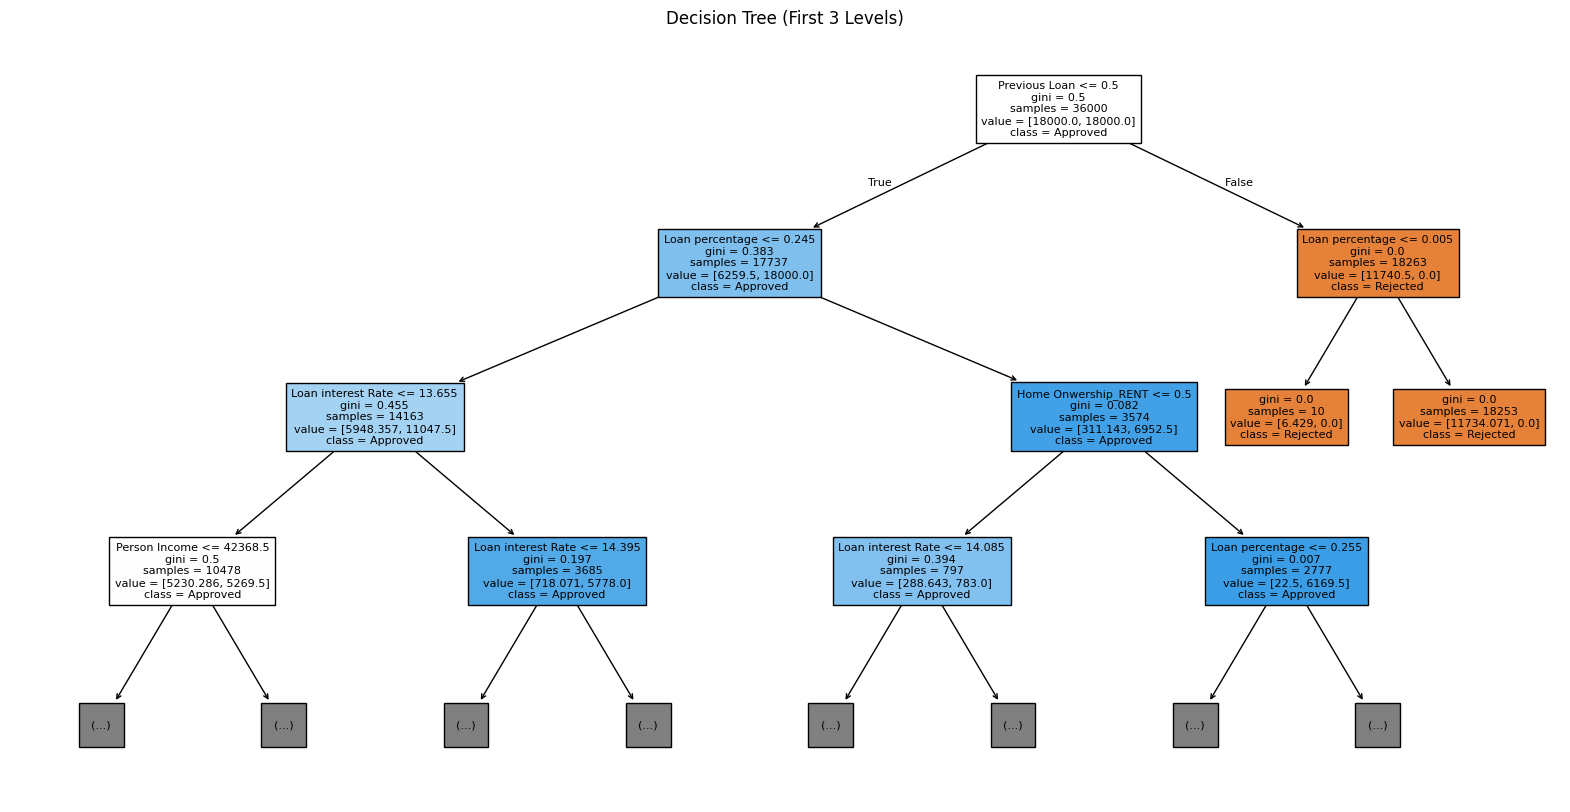

In [41]:
plt.figure(figsize=(20,10))
plot_tree(model, max_depth=3, feature_names=X.columns,
          class_names=["Rejected", "Approved"], filled=True, fontsize=8)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

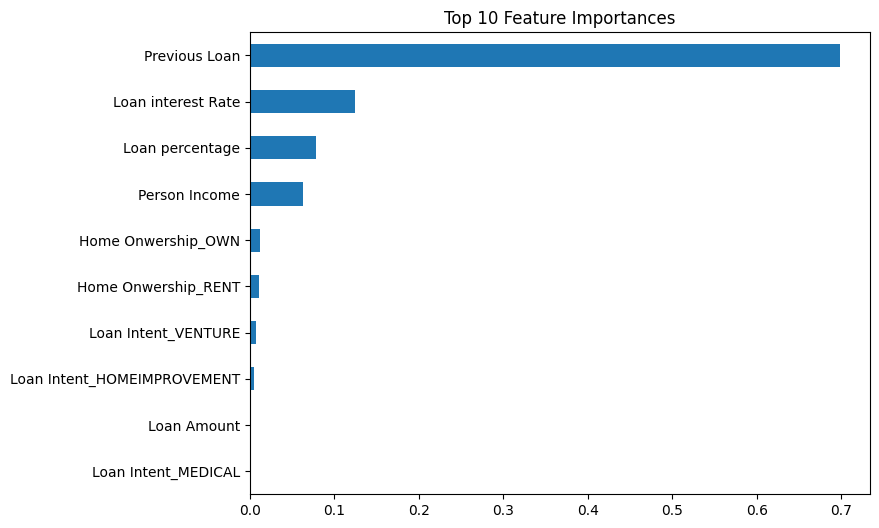

Previous Loan                  0.699172
Loan interest Rate             0.124764
Loan percentage                0.078281
Person Income                  0.063360
Home Onwership_OWN             0.011449
Home Onwership_RENT            0.010353
Loan Intent_VENTURE            0.006850
Loan Intent_HOMEIMPROVEMENT    0.004612
Loan Amount                    0.000979
Loan Intent_MEDICAL            0.000179
dtype: float64


In [42]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

print(importances.head(10))

In [43]:
print(pd.crosstab(df["Previous Loan"], df["Loan Status"], normalize="index") * 100)

Loan Status             0          1
Previous Loan                       
0               54.836961  45.163039
1              100.000000   0.000000
